# Statistical Factor Models for S&P 500

## Motivation

In portfolio management we need to estimate the **covariance matrix** $\Sigma$ of asset returns.
For $n$ assets and $T$ observations the sample covariance

$$
\hat{\Sigma} = \frac{1}{T} R^\top R, \qquad R \in \mathbb{R}^{T \times n}
$$

contains $\tfrac{n(n+1)}{2}$ free parameters. When $n$ is comparable to $T$
(for the S&P 500, $n \approx 500$ and a 5-year daily window gives $T \approx 1{,}250$)
the sample covariance is **noisy and ill-conditioned**.

**Statistical factor models** attack this problem by assuming that returns are driven
by a small number $k \ll n$ of latent factors:

$$
r_t = B f_t + \varepsilon_t, \qquad t = 1, \dots, T
$$

where:
- $r_t \in \mathbb{R}^n$ — vector of asset returns on day $t$
- $B \in \mathbb{R}^{n \times k}$ — **factor loadings** (how each asset loads on each factor)
- $f_t \in \mathbb{R}^k$ — **factor returns** (unobservable, estimated from data)
- $\varepsilon_t \in \mathbb{R}^n$ — **idiosyncratic** residuals (approximately uncorrelated across assets)

The implied covariance is:

$$
\Sigma = B \, \Sigma_f \, B^\top + D
$$

where $\Sigma_f = \text{Cov}(f_t)$ is $k \times k$ and $D$ is a diagonal matrix
of idiosyncratic variances. This has only $nk + n$ parameters instead of $\tfrac{n(n+1)}{2}$.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats, optimize
from scipy.linalg import svd
import warnings
warnings.filterwarnings('ignore')

import requests
import wrds

# Plot style
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# ── Key parameters ───────────────────────────────────────────
START_DATE = '2020-01-01'   
END_DATE   = '2024-12-31'

## S&P 500 Constituents

In [2]:
URL = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
resp = requests.get(URL, headers={"User-Agent": "Mozilla/5.0"})
resp.raise_for_status()

tables = pd.read_html(resp.text)
sp500_table = tables[0]

# Clean tickers
tickers_wiki = sp500_table['Symbol'].str.strip().tolist()

# CRSP convention: '.' → '/'
tickers_crsp = [t.replace('.', '/') for t in tickers_wiki]
ticker_map = dict(zip(tickers_crsp, tickers_wiki))

print(f"Found {len(tickers_wiki)} tickers from Wikipedia.")
print("Sample:", tickers_wiki[:10])
print("\nSector breakdown:")
print(sp500_table['GICS Sector'].value_counts())

Found 503 tickers from Wikipedia.
Sample: ['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']

Sector breakdown:
GICS Sector
Industrials               79
Financials                76
Information Technology    73
Health Care               59
Consumer Discretionary    48
Consumer Staples          35
Utilities                 31
Real Estate               31
Materials                 26
Communication Services    23
Energy                    22
Name: count, dtype: int64


## Download Data from WRDS

In [3]:
db = wrds.Connection()  # will prompt for username/password

tickers = tickers_crsp

# ── Build ticker string for SQL ──────────────────────────────
# Escape single quotes and build the IN clause
ticker_str = ", ".join([f"'{t}'" for t in tickers])

sql = f"""
SELECT
    d.date,
    n.ticker,
    d.permno,
    d.prc,
    d.ret,
    d.shrout,
    d.vol
FROM crsp.dsf AS d
INNER JOIN crsp.msenames AS n
    ON d.permno = n.permno
    AND d.date >= n.namedt
    AND d.date <= n.nameendt
WHERE n.ticker IN ({ticker_str})
    AND d.date BETWEEN '{START_DATE}' AND '{END_DATE}'
    AND n.shrcd IN (10, 11)
    AND n.exchcd IN (1, 2, 3)
ORDER BY d.date, n.ticker
"""

print("Querying WRDS...")
df_raw = db.raw_sql(sql, date_cols=['date'])
print(f"Downloaded {len(df_raw):,} rows for {df_raw['ticker'].nunique()} unique tickers.")
print(f"Date range: {df_raw['date'].min()} to {df_raw['date'].max()}")

WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
Querying WRDS...
Downloaded 537,881 rows for 437 unique tickers.
Date range: 2020-01-02 00:00:00 to 2024-12-31 00:00:00


## Returns Matrix

We pivot the long-format CRSP data into a **wide-format matrix**

$$
R \in \mathbb{R}^{T \times n}
$$

where row $t$ is the cross-section of returns on date $t$ and column $i$
is the time-series of returns for asset $i$.

### Cleaning steps

1. **Deduplicate**: if a ticker maps to multiple PERMNOs (due to corporate actions),
   keep the PERMNO with the most observations.
2. **Drop sparse columns**: remove stocks missing more than 5% of dates.
3. **Drop incomplete rows**: remove any date with remaining `NaN`s.

### The critical ratio $\gamma = n / T$

Random matrix theory tells us that the behaviour of the sample covariance
depends crucially on the ratio

$$
\gamma \;=\; \frac{n}{T}.
$$

When $\gamma$ is small (e.g. 0.01), the sample covariance is a good estimator.
When $\gamma$ is closer to 1, the noise eigenvalues spread over a wide band
given by the **Marchenko–Pastur** distribution (discussed below), and naive PCA breaks down.

In [4]:
# Map CRSP tickers back to Wikipedia tickers
df_raw['ticker_clean'] = df_raw['ticker'].map(ticker_map).fillna(df_raw['ticker'])

# Deduplicate: keep PERMNO with most observations per ticker
permno_counts = (
    df_raw.groupby(['ticker_clean', 'permno'])['date']
    .count()
    .reset_index(name='n_obs')
)
best_permno = (
    permno_counts
    .sort_values('n_obs', ascending=False)
    .drop_duplicates(subset='ticker_clean', keep='first')
)
df = df_raw.merge(best_permno[['ticker_clean', 'permno']], on=['ticker_clean', 'permno'])

# Pivot to wide format: rows = dates, columns = tickers
returns_df = df.pivot_table(index='date', columns='ticker_clean', values='ret')
print(f"Returns matrix shape (before cleaning): {returns_df.shape}")

# Drop stocks with too much missing data
threshold = 0.05
missing_frac = returns_df.isnull().mean()
keep_cols = missing_frac[missing_frac < threshold].index
returns_df = returns_df[keep_cols]

# Drop dates with any remaining NaN
returns_df = returns_df.dropna()
print(f"Returns matrix shape (after cleaning):  {returns_df.shape}")

n = returns_df.shape[1]   # number of assets
T = returns_df.shape[0]   # number of observations
gamma = n / T

print(f"\nn = {n} assets,  T = {T} observations")
print(f"γ = n/T = {gamma:.4f}")
print(f"Marchenko-Pastur upper edge (for σ²=1): λ₊ = (1 + √γ)² = {(1 + np.sqrt(gamma))**2:.4f}")

Returns matrix shape (before cleaning): (1258, 437)
Returns matrix shape (after cleaning):  (1195, 406)

n = 406 assets,  T = 1195 observations
γ = n/T = 0.3397
Marchenko-Pastur upper edge (for σ²=1): λ₊ = (1 + √γ)² = 2.5055


Before fitting any model, we inspect three distributions:

1. **Cross-sectional distribution of annualised mean returns** — tells us whether
   there are stocks with extreme average performance (possible data issues).

2. **Cross-sectional distribution of annualised volatilities** — typical S&P 500
   stocks have $\sigma \approx 25\text{–}40\%$ per year.

3. **Distribution of pairwise correlations** — the median pairwise correlation
   of S&P 500 stocks is typically $\rho \approx 0.25\text{–}0.35$. This positive
   average correlation is driven by the **market factor** (PC1) and is the main
   reason diversification works — but also why a single factor explains so much variance.

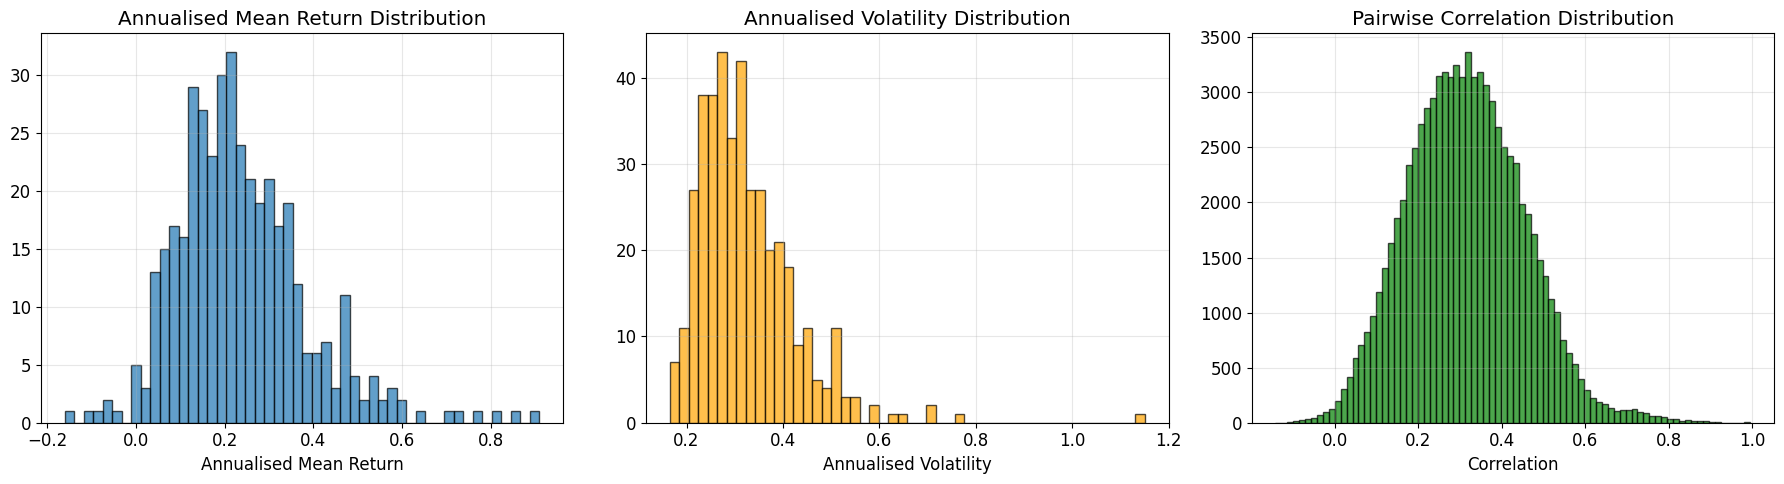

Median pairwise correlation: 0.3097
Mean annualised vol: 0.3249


In [5]:
R = returns_df.values.astype(np.float64)  # T × n numpy array
tickers = returns_df.columns.tolist()
dates = returns_df.index

# Summary statistics
mean_ret = R.mean(axis=0)
std_ret  = R.std(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(mean_ret * 252, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Annualised Mean Return Distribution')
axes[0].set_xlabel('Annualised Mean Return')

axes[1].hist(std_ret * np.sqrt(252), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('Annualised Volatility Distribution')
axes[1].set_xlabel('Annualised Volatility')

corr_matrix = np.corrcoef(R.T)
upper_tri = corr_matrix[np.triu_indices_from(corr_matrix, k=1)]
axes[2].hist(upper_tri, bins=80, edgecolor='black', alpha=0.7, color='green')
axes[2].set_title('Pairwise Correlation Distribution')
axes[2].set_xlabel('Correlation')

plt.tight_layout()
plt.show()

print(f"Median pairwise correlation: {np.median(upper_tri):.4f}")
print(f"Mean annualised vol: {(std_ret * np.sqrt(252)).mean():.4f}")

## SVD Decomposition

### The key factorisation

The **Singular Value Decomposition** of the demeaned returns matrix is

$$
\tilde{R} = U \, S \, V^\top
$$

where:
- $\tilde{R} = R - \bar{R}$ is the $T \times n$ demeaned returns matrix
- $U \in \mathbb{R}^{T \times n}$ has orthonormal columns ($U^\top U = I_n$)
- $S = \text{diag}(s_1, \dots, s_n)$ with $s_1 \ge s_2 \ge \cdots \ge s_n \ge 0$
- $V \in \mathbb{R}^{n \times n}$ is orthogonal ($V^\top V = V V^\top = I_n$)

### Connection to eigenvalues of the sample covariance

The sample covariance matrix is

$$
\hat{\Sigma} = \frac{1}{T} \tilde{R}^\top \tilde{R}
             = V \left(\frac{S^2}{T}\right) V^\top
$$

so the **eigenvalues** of $\hat{\Sigma}$ are $\lambda_i = s_i^2 / T$ and the
**eigenvectors** are the columns of $V$.

### Interpreting the decomposition

- **Scree plot** of $\lambda_1 \ge \lambda_2 \ge \cdots$: a steep initial drop
  followed by a flat tail suggests a low-rank factor structure.
- **Cumulative variance explained**: $\sum_{i=1}^k \lambda_i / \sum_{i=1}^n \lambda_i$.

Top 20 eigenvalues of sample covariance (×10⁴):
------------------------------------------------------------
  PC 1:  eigenvalue = 0.060747    explained = 32.50%    cumulative = 32.50%
  PC 2:  eigenvalue = 0.014540    explained =  7.78%    cumulative = 40.28%
  PC 3:  eigenvalue = 0.006955    explained =  3.72%    cumulative = 44.00%
  PC 4:  eigenvalue = 0.004630    explained =  2.48%    cumulative = 46.48%
  PC 5:  eigenvalue = 0.004206    explained =  2.25%    cumulative = 48.73%
  PC 6:  eigenvalue = 0.003074    explained =  1.64%    cumulative = 50.37%
  PC 7:  eigenvalue = 0.002482    explained =  1.33%    cumulative = 51.70%
  PC 8:  eigenvalue = 0.002299    explained =  1.23%    cumulative = 52.93%
  PC 9:  eigenvalue = 0.002181    explained =  1.17%    cumulative = 54.10%
  PC10:  eigenvalue = 0.002061    explained =  1.10%    cumulative = 55.20%
  PC11:  eigenvalue = 0.001906    explained =  1.02%    cumulative = 56.22%
  PC12:  eigenvalue = 0.001748    explained =  0.94%   

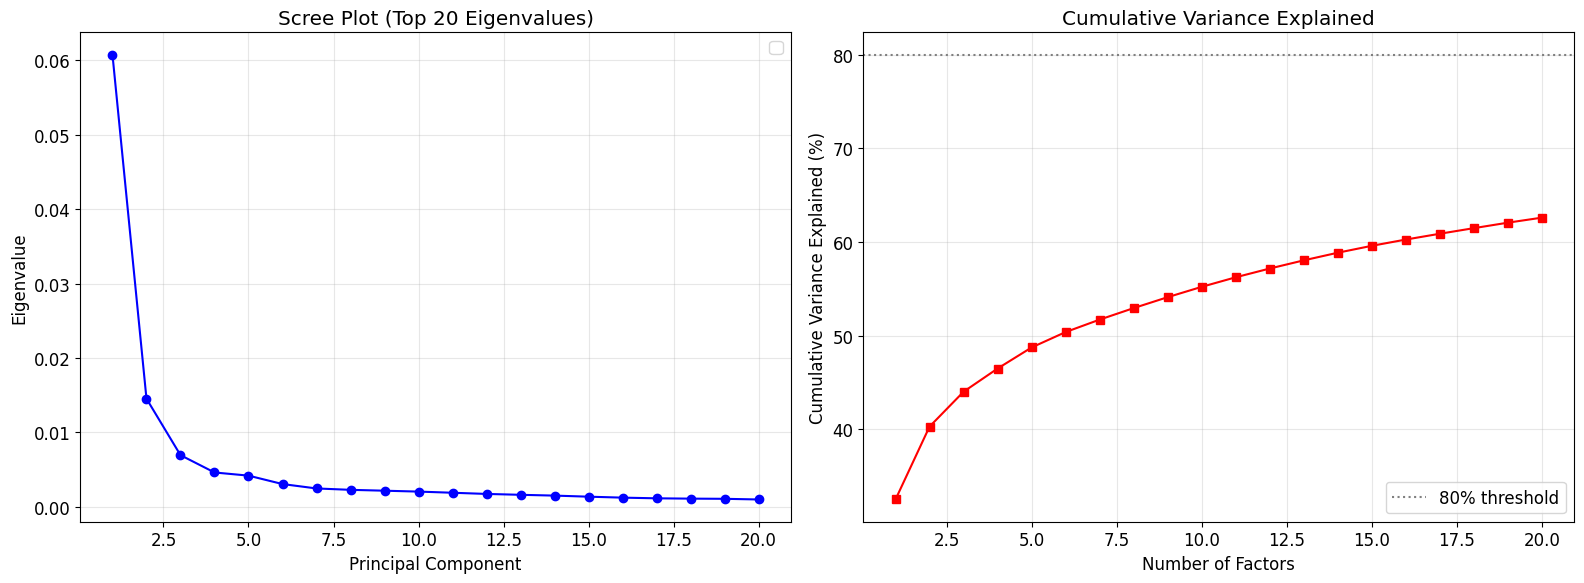

In [6]:
R_dm = R - R.mean(axis=0, keepdims=True)  # T × n, demeaned

# Full SVD
U, s, Vt = svd(R_dm, full_matrices=False)

# Eigenvalues of the sample covariance (1/T) R'R
eigenvalues = s**2 / T
explained_var = eigenvalues / eigenvalues.sum()
cumulative_var = np.cumsum(explained_var)

# Print top eigenvalues
eigenvalue_num = 20
print(f"Top {eigenvalue_num} eigenvalues of sample covariance (×10⁴):")
print("-" * 60)
for i in range(eigenvalue_num):
    print(f"  PC{i+1:2d}:  eigenvalue = {eigenvalues[i]:.6f}  "
          f"  explained = {explained_var[i]*100:5.2f}%  "
          f"  cumulative = {cumulative_var[i]*100:5.2f}%")

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(range(1, eigenvalue_num+1), eigenvalues[:eigenvalue_num], 'bo-', markersize=6)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Eigenvalue')
axes[0].set_title(f'Scree Plot (Top {eigenvalue_num} Eigenvalues)')
axes[0].legend()

axes[1].plot(range(1, eigenvalue_num+1), cumulative_var[:eigenvalue_num] * 100, 'rs-', markersize=6)
axes[1].set_xlabel('Number of Factors')
axes[1].set_ylabel('Cumulative Variance Explained (%)')
axes[1].set_title('Cumulative Variance Explained')
axes[1].axhline(y=80, color='gray', linestyle=':', label='80% threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

## Marchenko-Pastur Distribution & Signal Detection

### The problem

The scree plot shows a "drop" after a few eigenvalues, but **where exactly should
we cut?** Looking for an "elbow" is subjective. Random matrix theory gives us
a **principled, quantitative threshold**.

### Null hypothesis: pure noise

Suppose returns had **no** factor structure at all — every entry of $\tilde{R}$
were i.i.d. $\mathcal{N}(0, \sigma^2)$. Even then, the sample covariance
$\hat{\Sigma} = \tilde{R}^\top \tilde{R} / T$ is **not** $\sigma^2 I$ —
it has a spread of eigenvalues. As $n, T \to \infty$ with $\gamma = n/T$ fixed,
the eigenvalue distribution converges to the **Marchenko–Pastur (MP) law**:

$$
f_{\text{MP}}(\lambda) =
\frac{\sqrt{(\lambda_+ - \lambda)(\lambda - \lambda_-)}}{2\pi\,\gamma\,\sigma^2\,\lambda},
\qquad \lambda \in [\lambda_-, \lambda_+]
$$

with edges:

$$
\lambda_{\pm} = \sigma^2 \left(1 \pm \sqrt{\gamma}\right)^2
$$

### Signal detection rule

Any sample eigenvalue $\hat{\lambda}_i > \lambda_+$ **cannot** be explained by
noise alone — it corresponds to a **true** factor. The number of eigenvalues
above $\lambda_+$ gives us the number of detectable factors $k$.

### Practical refinement

In practice the "noise variance" $\sigma^2$ is not exactly 1 (even after
standardising returns) because the signal eigenvalues steal variance from the
bulk. We estimate $\sigma^2$ by fitting the MP density to the bulk eigenvalues
via maximum likelihood, then recompute $\lambda_+$.

Fitted σ² = 0.640090
λ₊ = 1.603752
n_signals = 23


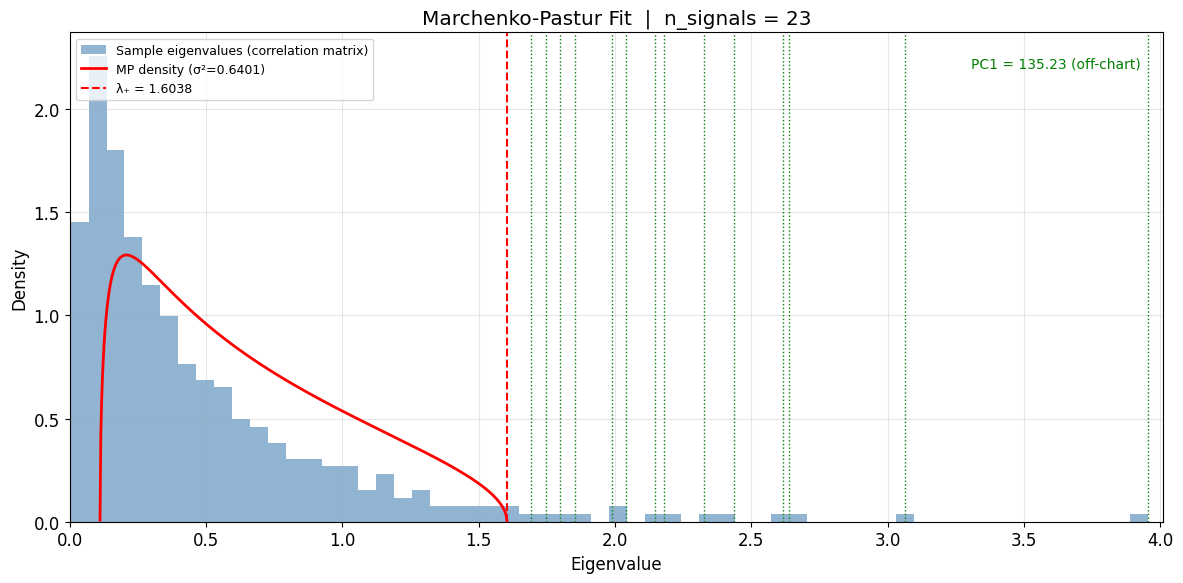

In [7]:
def marchenko_pastur_pdf(x, gamma, sigma2=1.0):
    """Marchenko–Pastur density."""
    lp = sigma2 * (1 + np.sqrt(gamma))**2
    lm = sigma2 * (1 - np.sqrt(gamma))**2
    density = np.zeros_like(x, dtype=float)
    mask = (x > lm) & (x < lp)
    density[mask] = (
        np.sqrt((lp - x[mask]) * (x[mask] - lm))
        / (2 * np.pi * gamma * sigma2 * x[mask])
    )
    return density


def mp_edges(gamma, sigma2=1.0):
    """Return (λ₋, λ₊)."""
    return sigma2 * (1 - np.sqrt(gamma))**2, sigma2 * (1 + np.sqrt(gamma))**2


# TODO: Figure out significant factors based on the eigenvalues from the return matrix

R_std = R_dm / R_dm.std(axis=0)
_, s_c, Vt_c = svd(R_std, full_matrices=False)
eigenvalues_corr = s_c**2 / T

sigma2_fit = 1.0
for _ in range(50):
    lm_fit, lp_fit = mp_edges(gamma, sigma2_fit)
    bulk = eigenvalues_corr[(eigenvalues_corr >= lm_fit) & (eigenvalues_corr <= lp_fit)]
    if len(bulk) == 0:
        break
    result = optimize.minimize_scalar(
        lambda s2: -np.sum(np.log(np.clip(marchenko_pastur_pdf(bulk, gamma, s2), 1e-300, None))),
        bounds=(0.01, 2.0),
        method='bounded'
    )
    sigma2_new = result.x
    if abs(sigma2_new - sigma2_fit) < 1e-8:
        break
    sigma2_fit = sigma2_new

lm_fit, lp_fit = mp_edges(gamma, sigma2_fit)
n_signals = int(np.sum(eigenvalues_corr > lp_fit))
signal_eigs = eigenvalues_corr[:n_signals]

print(f"Fitted σ² = {sigma2_fit:.6f}")
print(f"λ₊ = {lp_fit:.6f}")
print(f"n_signals = {n_signals}")

plot_max = lp_fit * 2.5
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(eigenvalues_corr[eigenvalues_corr <= plot_max], bins=60, density=True,
        alpha=0.6, color='steelblue', label='Sample eigenvalues (correlation matrix)')

x_grid = np.linspace(lm_fit + 1e-6, lp_fit - 1e-6, 500)
ax.plot(x_grid, marchenko_pastur_pdf(x_grid, gamma, sigma2_fit),
        'r-', lw=2, label=f'MP density (σ²={sigma2_fit:.4f})')

ax.axvline(lp_fit, color='red', linestyle='--', lw=1.5, label=f'λ₊ = {lp_fit:.4f}')

for i, ev in enumerate(signal_eigs):
    if ev <= plot_max:
        ax.axvline(ev, color='green', linestyle=':', lw=1.0,
                   label=f'PC{i+1} = {ev:.4f}' if i < 5 else None)

ax.text(0.98, 0.95, f'PC1 = {signal_eigs[0]:.2f} (off-chart)',
        transform=ax.transAxes, ha='right', va='top', color='green', fontsize=10)

ax.set_xlim(0, plot_max)
ax.set_xlabel('Eigenvalue')
ax.set_ylabel('Density')
ax.set_title(f'Marchenko-Pastur Fit  |  n_signals = {n_signals}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Baik-Ben Arous-Péché (BBP) Phase Transition & Spike Detection

### Beyond counting eigenvalues: are the eigenvectors reliable?

Knowing that $\hat{\lambda}_i > \lambda_+$ tells us a signal exists, but it
does **not** tell us how accurately we've estimated the corresponding
eigenvector. The **Baik–Ben Arous–Péché (BBP)** transition characterises this.

### The spike forward map

Suppose the true population covariance has a spike eigenvalue $\ell$ (all others
equal to $\sigma^2$). Then as $n, T \to \infty$:

$$
\hat{\lambda} \;\xrightarrow{\;\;a.s.\;\;}\;
\begin{cases}
\ell \left(1 + \dfrac{\gamma}{\ell - 1}\right) & \text{if } \ell > 1 + \sqrt{\gamma}\\[8pt]
(1 + \sqrt{\gamma})^2 & \text{if } \ell \le 1 + \sqrt{\gamma}
\end{cases}
$$

**Interpretation:**
- If the true signal $\ell$ is strong enough (above $1 + \sqrt{\gamma}$), the sample
  eigenvalue "detaches" from the MP bulk but is **biased upward**.
- If $\ell$ is too weak, the sample eigenvalue gets swallowed by the bulk —
  indistinguishable from noise. This is the **BBP threshold**.

### Eigenvector alignment

The squared cosine between the true eigenvector $u$ and sample eigenvector $\hat{u}$ is:

$$
|\langle u, \hat{u} \rangle|^2
\;\to\;
\begin{cases}
\dfrac{1 - \gamma/(\ell - 1)^2}{1 + \gamma/(\ell - 1)} & \text{if } \ell > 1 + \sqrt{\gamma}\\[8pt]
0 & \text{if } \ell \le 1 + \sqrt{\gamma}
\end{cases}
$$

Even above threshold, the alignment is **less than 1** — the sample eigenvector
is rotated away from truth. Near the threshold, the alignment approaches **zero**.
This is why naive PCA is unreliable for weak factors.

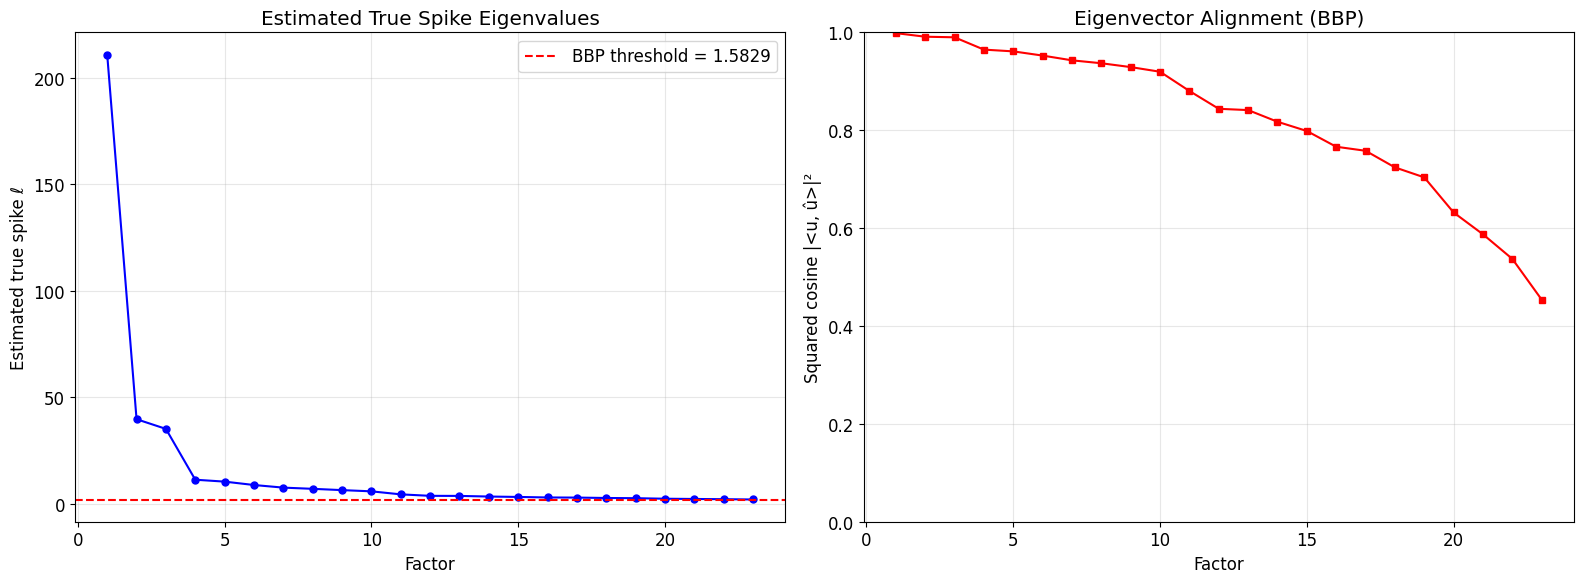

BBP threshold (1+√γ) = 1.5829
PC1:  ℓ = 210.9251,  alignment = 0.9984
PC23: ℓ = 1.9422,  alignment = 0.4537


In [8]:
# TODO: Check the alignment of eigenvalues and comment on the result.

lambda_hat_norm = eigenvalues_corr[:n_signals] / sigma2_fit

ells = []
alignments = []
for lh in lambda_hat_norm:
    b = 1 + lh - gamma
    disc = b**2 - 4 * lh
    ell = 0.5 * (b + np.sqrt(max(disc, 0))) 
    ells.append(ell)
    alignment = (1 - gamma / (ell - 1)**2) / (1 + gamma / (ell - 1))
    alignments.append(alignment)

ells = np.array(ells)
alignments = np.array(alignments)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(range(1, n_signals + 1), ells, 'bo-', markersize=5)
axes[0].axhline(1 + np.sqrt(gamma), color='red', linestyle='--', label=f'BBP threshold = {1+np.sqrt(gamma):.4f}')
axes[0].set_xlabel('Factor')
axes[0].set_ylabel('Estimated true spike ℓ')
axes[0].set_title('Estimated True Spike Eigenvalues')
axes[0].legend()

axes[1].plot(range(1, n_signals + 1), alignments, 'rs-', markersize=5)
axes[1].set_xlabel('Factor')
axes[1].set_ylabel('Squared cosine |<u, û>|²')
axes[1].set_title('Eigenvector Alignment (BBP)')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print(f"BBP threshold (1+√γ) = {1+np.sqrt(gamma):.4f}")
print(f"PC1:  ℓ = {ells[0]:.4f},  alignment = {alignments[0]:.4f}")
print(f"PC{n_signals}: ℓ = {ells[-1]:.4f},  alignment = {alignments[-1]:.4f}")

PC1 alignment = 0.998 → the market factor is reliably estimated.

PC23 alignment = 0.454 → weak factors near the BBP threshold have unreliable eigenvector estimates. This is precisely why naive PCA breaks down for weak factors, and motivates the eigenvalue shrinkage in the later cells.

## Construct the PCA Factor Model

### Choosing $k$

From the MP analysis above, we determined $k = $ `n_signals` factors are
statistically significant. We now extract:

| Object | Symbol | Shape | How to compute |
|--------|--------|-------|----------------|
| Factor loadings | $B$ | $n \times k$ | First $k$ right singular vectors: $B = V_{:, 1:k}$ |
| Factor returns | $\hat{f}_t$ | $T \times k$ | Project returns: $\hat{F} = \tilde{R} \, B$ |
| Residuals | $\hat{\varepsilon}$ | $T \times n$ | $\hat{\varepsilon} = \tilde{R} - \hat{F} B^\top$ |

### Variance decomposition

Total variance decomposes as:

$$
\underbrace{\|\tilde{R}\|_F^2}_{\text{total}}
\;=\;
\underbrace{\|\hat{F} B^\top\|_F^2}_{\text{factor (systematic)}}
\;+\;
\underbrace{\|\hat{\varepsilon}\|_F^2}_{\text{idiosyncratic}}
$$

The factor part equals $\sum_{i=1}^k s_i^2$ and the residual part equals
$\sum_{i=k+1}^n s_i^2$ — this is the Eckart–Young theorem.

### Per-stock $R^2$

For each stock $i$, the fraction of variance explained by the factors is:

$$
R_i^2 = 1 - \frac{\sum_t \hat{\varepsilon}_{ti}^2}{\sum_t \tilde{R}_{ti}^2}
$$

Stocks with low $R^2$ are driven primarily by idiosyncratic news; those with
high $R^2$ move in lockstep with the statistical factors.


Total variance:       223.360430
Factor variance:      143.195700  (64.11%)
Idiosyncratic variance: 80.164730  (35.89%)


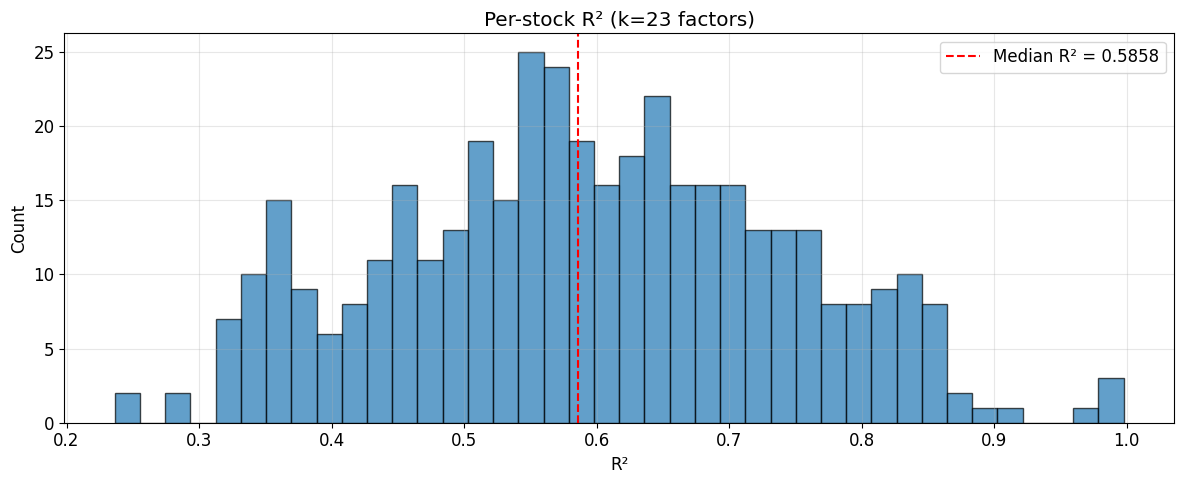

Median R²: 0.5858
Min R²:    0.2364
Max R²:    0.9977


In [9]:
# TODO: Build a factor model with the significant factors determined above

B = Vt[:n_signals].T

F_hat = R_dm @ B

eps_hat = R_dm - F_hat @ B.T

total_var = np.sum(R_dm**2)
factor_var = np.sum((F_hat @ B.T)**2)
idio_var = np.sum(eps_hat**2)

print(f"Total variance:       {total_var:.6f}")
print(f"Factor variance:      {factor_var:.6f}  ({factor_var/total_var*100:.2f}%)")
print(f"Idiosyncratic variance: {idio_var:.6f}  ({idio_var/total_var*100:.2f}%)")

R2_per_stock = 1 - np.sum(eps_hat**2, axis=0) / np.sum(R_dm**2, axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(R2_per_stock, bins=40, edgecolor='black', alpha=0.7)
ax.set_xlabel('R²')
ax.set_ylabel('Count')
ax.set_title(f'Per-stock R² (k={n_signals} factors)')
ax.axvline(np.median(R2_per_stock), color='red', linestyle='--', label=f'Median R² = {np.median(R2_per_stock):.4f}')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Median R²: {np.median(R2_per_stock):.4f}")
print(f"Min R²:    {np.min(R2_per_stock):.4f}")
print(f"Max R²:    {np.max(R2_per_stock):.4f}")

## Factor Loading Interpretation

PCA factors are **statistical** — they are not labelled "market", "value",
"momentum", etc. by construction. But we can interpret them by examining
their **loadings** $B_{i,j}$ (how much stock $i$ loads on factor $j$) and
grouping by GICS sector.

**Typical pattern for US equities:**

| Factor | Loadings pattern | Economic interpretation |
|--------|-----------------|------------------------|
| PC1 | All loadings positive, roughly uniform | Market factor |
| PC2 | Tech positive, Energy/Financials negative | Growth vs. Value |
| PC3 | Financials positive, Utilities/Staples negative | Rate sensitivity |
| PC4+ | Sector or industry rotation | Harder to name |

*Question: Can you verify if this is true?*

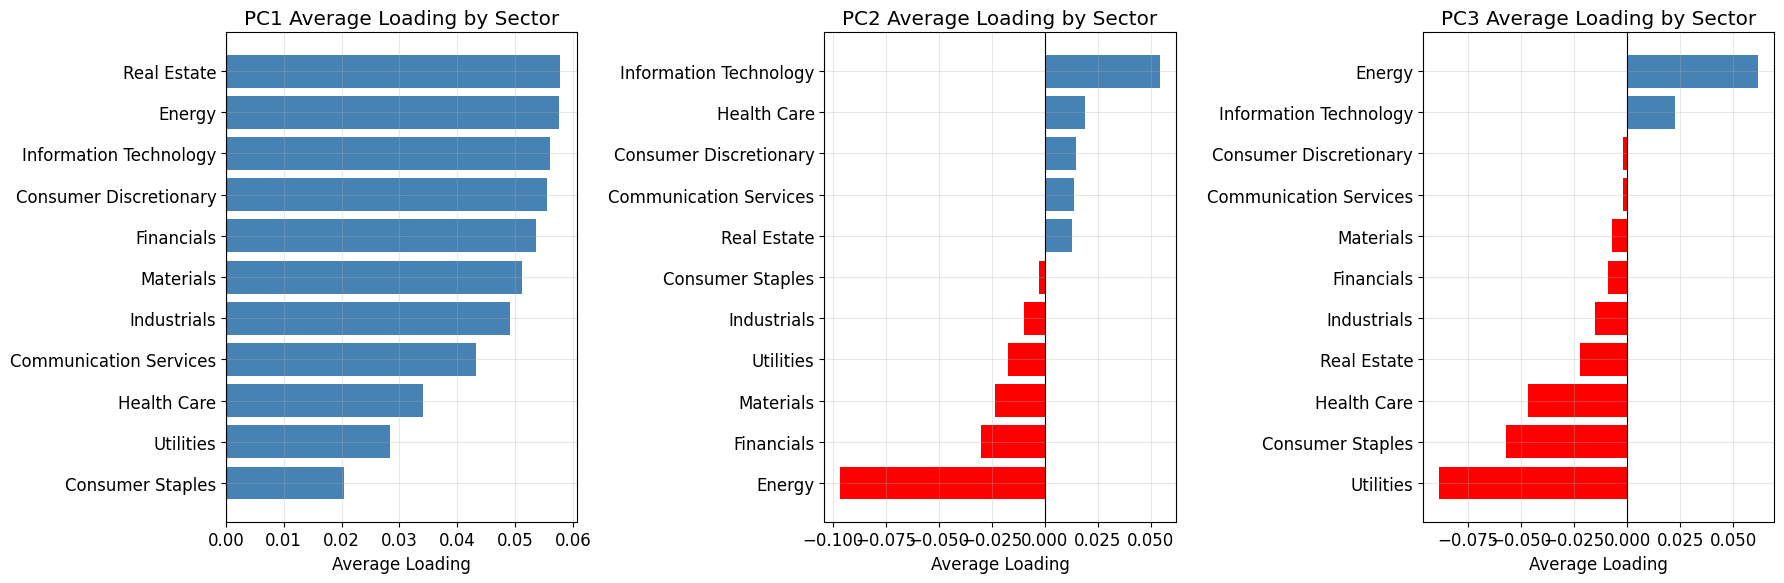

In [10]:
# TODO: Verification from Aabove

sector_map = sp500_table.set_index('Symbol')['GICS Sector'].to_dict()
sectors = pd.Series([sector_map.get(t, 'Unknown') for t in tickers], index=tickers)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for pc_idx in range(3):
    loadings = pd.Series(B[:, pc_idx], index=tickers)
    sector_mean = loadings.groupby(sectors).mean().sort_values()
    
    colors = ['red' if v < 0 else 'steelblue' for v in sector_mean.values]
    axes[pc_idx].barh(sector_mean.index, sector_mean.values, color=colors)
    axes[pc_idx].axvline(0, color='black', linewidth=0.8)
    axes[pc_idx].set_title(f'PC{pc_idx+1} Average Loading by Sector')
    axes[pc_idx].set_xlabel('Average Loading')

plt.tight_layout()
plt.show()

In [11]:
sector_mean_pc1 = pd.Series(B[:, 0], index=tickers).groupby(sectors).mean()
sector_mean_pc2 = pd.Series(B[:, 1], index=tickers).groupby(sectors).mean()
sector_mean_pc3 = pd.Series(B[:, 2], index=tickers).groupby(sectors).mean()

print("PC1 (expect all positive):")
for s in ['Information Technology', 'Energy', 'Financials', 'Utilities', 'Consumer Staples']:
    print(f"  {s}: {sector_mean_pc1[s]:.4f}")

print("\nPC2 (expect IT positive, Energy/Financials negative):")
for s in ['Information Technology', 'Energy', 'Financials']:
    print(f"  {s}: {sector_mean_pc2[s]:.4f}")

print("\nPC3 (expect Financials positive, Utilities/Consumer Staples negative):")
for s in ['Financials', 'Utilities', 'Consumer Staples']:
    print(f"  {s}: {sector_mean_pc3[s]:.4f}")

PC1 (expect all positive):
  Information Technology: 0.0560
  Energy: 0.0577
  Financials: 0.0537
  Utilities: 0.0283
  Consumer Staples: 0.0205

PC2 (expect IT positive, Energy/Financials negative):
  Information Technology: 0.0541
  Energy: -0.0967
  Financials: -0.0303

PC3 (expect Financials positive, Utilities/Consumer Staples negative):
  Financials: -0.0089
  Utilities: -0.0889
  Consumer Staples: -0.0573


- PC1: all sector loadings positive (IT: 0.0560, Energy: 0.0577, Financials: 0.0537, Utilities: 0.0283, Consumer Staples: 0.0205) → confirmed
- PC2: IT positive (0.0541), Energy negative (-0.0967), Financials negative (-0.0303) → confirmed
- PC3: Utilities (-0.0889) and Consumer Staples (-0.0573) negative as expected, but Financials observed negative (-0.0089) contrary to expectation → not confirmed

## Cross-Sectional & Time-Series Regression Duality

### A uniqueness result

The SVD factorisation is the **unique** decomposition $\tilde{R} = \hat{F} B^\top$
such that both of the following hold simultaneously:

#### (a) Cross-sectional regression

Given loadings $B$, recover factor returns by regressing returns **across stocks**
at each date $t$:

$$
\hat{f}_t = (B^\top B)^{-1} B^\top r_t
$$

Since PCA loadings have orthonormal columns ($B^\top B = I_k$), this simplifies to
$\hat{f}_t = B^\top r_t$, which is exactly $\hat{F} = \tilde{R} B$.

#### (b) Time-series regression

Given factor returns $\hat{F}$, recover loadings by regressing each stock's
return **over time** on the factor returns:

$$
\hat{b}_i = (\hat{F}^\top \hat{F})^{-1} \hat{F}^\top r_i
$$

Since $\hat{F}^\top \hat{F} = S_k^2$ (diagonal), this yields exactly $B$.

#### (c) Factor orthogonality

By construction, PCA factors are **uncorrelated**: $\hat{F}^\top \hat{F}$ is diagonal.
This is a *statistical* convenience, not an economic claim — real factors may be correlated.



In [12]:
# TODO: Verification

BtB = B.T @ B
F_hat_cs = R_dm @ B
FtF = F_hat.T @ F_hat
B_hat_ts = np.linalg.solve(FtF, F_hat.T @ R_dm).T
off_diag = FtF - np.diag(np.diag(FtF))

print(f"(a) B^T B = I_k (max deviation): {np.max(np.abs(BtB - np.eye(n_signals))):.2e}")
print(f"    F_hat matches R_dm @ B (max diff): {np.max(np.abs(F_hat_cs - F_hat)):.2e}")
print(f"(b) B matches time-series OLS (max diff): {np.max(np.abs(B_hat_ts - B)):.2e}")
print(f"(c) F_hat^T F_hat off-diagonal (max abs): {np.max(np.abs(off_diag)):.2e}")
print(f"    F_hat^T F_hat diagonal (first 5): {np.diag(FtF)[:5]}")

(a) B^T B = I_k (max deviation): 3.33e-15
    F_hat matches R_dm @ B (max diff): 0.00e+00
(b) B matches time-series OLS (max diff): 3.33e-15
(c) F_hat^T F_hat off-diagonal (max abs): 7.97e-13
    F_hat^T F_hat diagonal (first 5): [72.59288932 17.37578739  8.31163208  5.53229914  5.02570283]


## Eigenvalue Shrinkage

### The bias problem

The BBP analysis above showed that sample eigenvalues are **biased upward**.
The spike forward map was:

$$
\hat{\lambda} = \ell \left(1 + \frac{\gamma}{\ell - 1}\right)
$$

### Inverting the map (debiasing)

To recover the true $\ell$ from the observed $\hat{\lambda}$, we solve the
quadratic and obtain:

$$
\eta(\hat{\lambda}) = \frac{1}{2}\left[
  (\hat{\lambda} - \gamma - 1) + \sqrt{(\hat{\lambda} - \gamma - 1)^2 - 4\gamma}
\right]
$$

A simpler (and asymptotically equivalent for large $\hat{\lambda}$) approximation is:

$$
\eta_{\text{simple}}(\hat{\lambda}) = \hat{\lambda} - \gamma
$$

### Reconstructing the shrunk covariance

We build the **debiased** covariance:

$$
\hat{\Omega}_{\text{shrunk}} = V_k \, \text{diag}(\eta(\hat{\lambda}_1), \dots, \eta(\hat{\lambda}_k)) \, V_k^\top
+ \hat{\sigma}^2 (I_n - V_k V_k^\top)
$$

This keeps the signal eigenvectors but corrects their eigenvalues, and replaces
the noise space with a single isotropic variance $\hat{\sigma}^2$.


In [13]:
def shrink_eigenvalue_exact(lambda_hat, gamma):
    """Invert the spike forward map (quadratic formula)."""
    a = lambda_hat - gamma - 1
    disc = a**2 - 4 * gamma
    if disc < 0:
        return np.nan
    return 0.5 * (a + np.sqrt(disc))


def shrink_eigenvalue_simple(lambda_hat, gamma):
    """Simple offset shrinkage: η = λ̂ − γ."""
    return lambda_hat - gamma


# TODO: Test eigenvalue shrinkage. Also check the condition number of the covariance matrix (this refers to certain numerical stability in calculations)

V_k = Vt_c[:n_signals].T
lambda_hat_norm = eigenvalues_corr[:n_signals] / sigma2_fit

shrunk_exact = np.array([shrink_eigenvalue_exact(lh, gamma) for lh in lambda_hat_norm])
shrunk_simple = np.array([shrink_eigenvalue_simple(lh, gamma) for lh in lambda_hat_norm])

Omega_exact = V_k @ np.diag(shrunk_exact * sigma2_fit) @ V_k.T + sigma2_fit * (np.eye(n) - V_k @ V_k.T)
Omega_simple = V_k @ np.diag(shrunk_simple * sigma2_fit) @ V_k.T + sigma2_fit * (np.eye(n) - V_k @ V_k.T)

sample_cov = R_std.T @ R_std / T
cond_sample = np.linalg.cond(sample_cov)
cond_exact = np.linalg.cond(Omega_exact)
cond_simple = np.linalg.cond(Omega_simple)

print(f"Condition number - sample covariance:          {cond_sample:.2f}")
print(f"Condition number - shrunk covariance (exact):  {cond_exact:.2f}")
print(f"Condition number - shrunk covariance (simple): {cond_simple:.2f}")

Condition number - sample covariance:          38819.58
Condition number - shrunk covariance (exact):  222.80
Condition number - shrunk covariance (simple): 210.93


- Sample covariance condition number: 38,819 — highly ill-conditioned, inverting this matrix is numerically unstable
- Shrunk covariance (exact): 222 — ~175x improvement
- Shrunk covariance (simple): 211 — comparable to exact, confirming the simple approximation η = λ̂ − γ is sufficient in practice

## Factor-Mimicking Portfolios (FMPs)

### Definition

The $j$-th factor-mimicking portfolio (FMP) is a portfolio of stocks whose
return **tracks** factor $j$ as closely as possible. Given loadings $B$,
the FMP weight vector is:

$$
w_j = B (B^\top B)^{-1} e_j
$$

where $e_j$ is the $j$-th standard basis vector. Since $B$ has orthonormal
columns, this simplifies to $w_j = B_{:,j}$ — the $j$-th column of $B$.

### Why this matters

The return of FMP $j$ is $w_j^\top r_t = B_{:,j}^\top r_t = \hat{f}_{j,t}$,
which is exactly the $j$-th PCA factor return. So the FMP **replicates** the
statistical factor using tradeable assets.

### Diversification & idiosyncratic risk

As $n \to \infty$ the idiosyncratic variance of the FMP portfolio vanishes:

$$
\text{Var}_{\text{idio}}(w_j^\top r_t)
= w_j^\top D \, w_j
= \sum_{i=1}^n B_{ij}^2 \, d_i
\approx \frac{\bar{d}}{\alpha n} \to 0
$$

where $\alpha$ is the fraction of stocks with non-negligible loadings and
$\bar{d}$ is the average idiosyncratic variance.

In [14]:
# TODO: Construct the factor-mimicking portfolio. Try to verify that each FMP does track each factor as close as possible.

W = B
FMP_ret = R_dm @ W

D = np.var(eps_hat, axis=0)
idio_var = np.array([B[:, j] @ np.diag(D) @ B[:, j] for j in range(n_signals)])
total_var_fmp = np.array([np.var(FMP_ret[:, j]) for j in range(n_signals)])
idio_frac = idio_var / total_var_fmp

for j in range(n_signals):
    print(f"PC{j+1:2d}: idiosyncratic fraction = {idio_frac[j]:.4f}")

PC 1: idiosyncratic fraction = 0.0030
PC 2: idiosyncratic fraction = 0.0131
PC 3: idiosyncratic fraction = 0.0206
PC 4: idiosyncratic fraction = 0.0309
PC 5: idiosyncratic fraction = 0.0278
PC 6: idiosyncratic fraction = 0.0651
PC 7: idiosyncratic fraction = 0.0569
PC 8: idiosyncratic fraction = 0.0801
PC 9: idiosyncratic fraction = 0.0708
PC10: idiosyncratic fraction = 0.0253
PC11: idiosyncratic fraction = 0.0555
PC12: idiosyncratic fraction = 0.1136
PC13: idiosyncratic fraction = 0.1167
PC14: idiosyncratic fraction = 0.1067
PC15: idiosyncratic fraction = 0.1621
PC16: idiosyncratic fraction = 0.1684
PC17: idiosyncratic fraction = 0.2159
PC18: idiosyncratic fraction = 0.2259
PC19: idiosyncratic fraction = 0.2297
PC20: idiosyncratic fraction = 0.2581
PC21: idiosyncratic fraction = 0.2830
PC22: idiosyncratic fraction = 0.2702
PC23: idiosyncratic fraction = 0.2832


- FMP weights are given by the columns of B; by construction, FMP returns exactly replicate factor returns in-sample (w_j^T r_t = f̂_{j,t}), making direct tracking verification trivial
- Instead, idiosyncratic fraction (w_j^T D w_j / Var(FMP_j)) is used as a proxy: lower values indicate the FMP return is driven more by systematic risk than idiosyncratic noise
- PC1 idiosyncratic fraction: 0.30% — near-perfect systematic exposure
- PC23 idiosyncratic fraction: 28.32% — weak factors carry substantially more idiosyncratic risk, consistent with the BBP alignment results above
- A rigorous out-of-sample tracking verification would require a separate test period

## Rolling PCA Stability Analysis

Factor loadings are **not constant** over time. The composition of the
"market factor" shifts as sector weights change; the second factor might
switch from "Growth vs. Value" to "Covid reopening vs. stay-at-home" in 2020.

Re-estimate PCA on a **rolling 1-year window** (252 trading days)
every month (21 days) and track three diagnostics:

1. **Rolling eigenvalues $\lambda_1, \lambda_2, \lambda_3$**: the first
   eigenvalue spikes during crises (March 2020, 2022 rate shock) as
   correlations rise and the market factor dominates.

2. **Rolling number of significant factors** (above the MP edge): this
   fluctuates as the signal-to-noise ratio changes.

3. **PC1 loading stability**: the cosine similarity $|\langle v_1^t, v_1^{t-1}\rangle|$
   between consecutive windows' PC1 loadings. Values close to 1 mean the
   factor is stable; drops indicate regime changes.

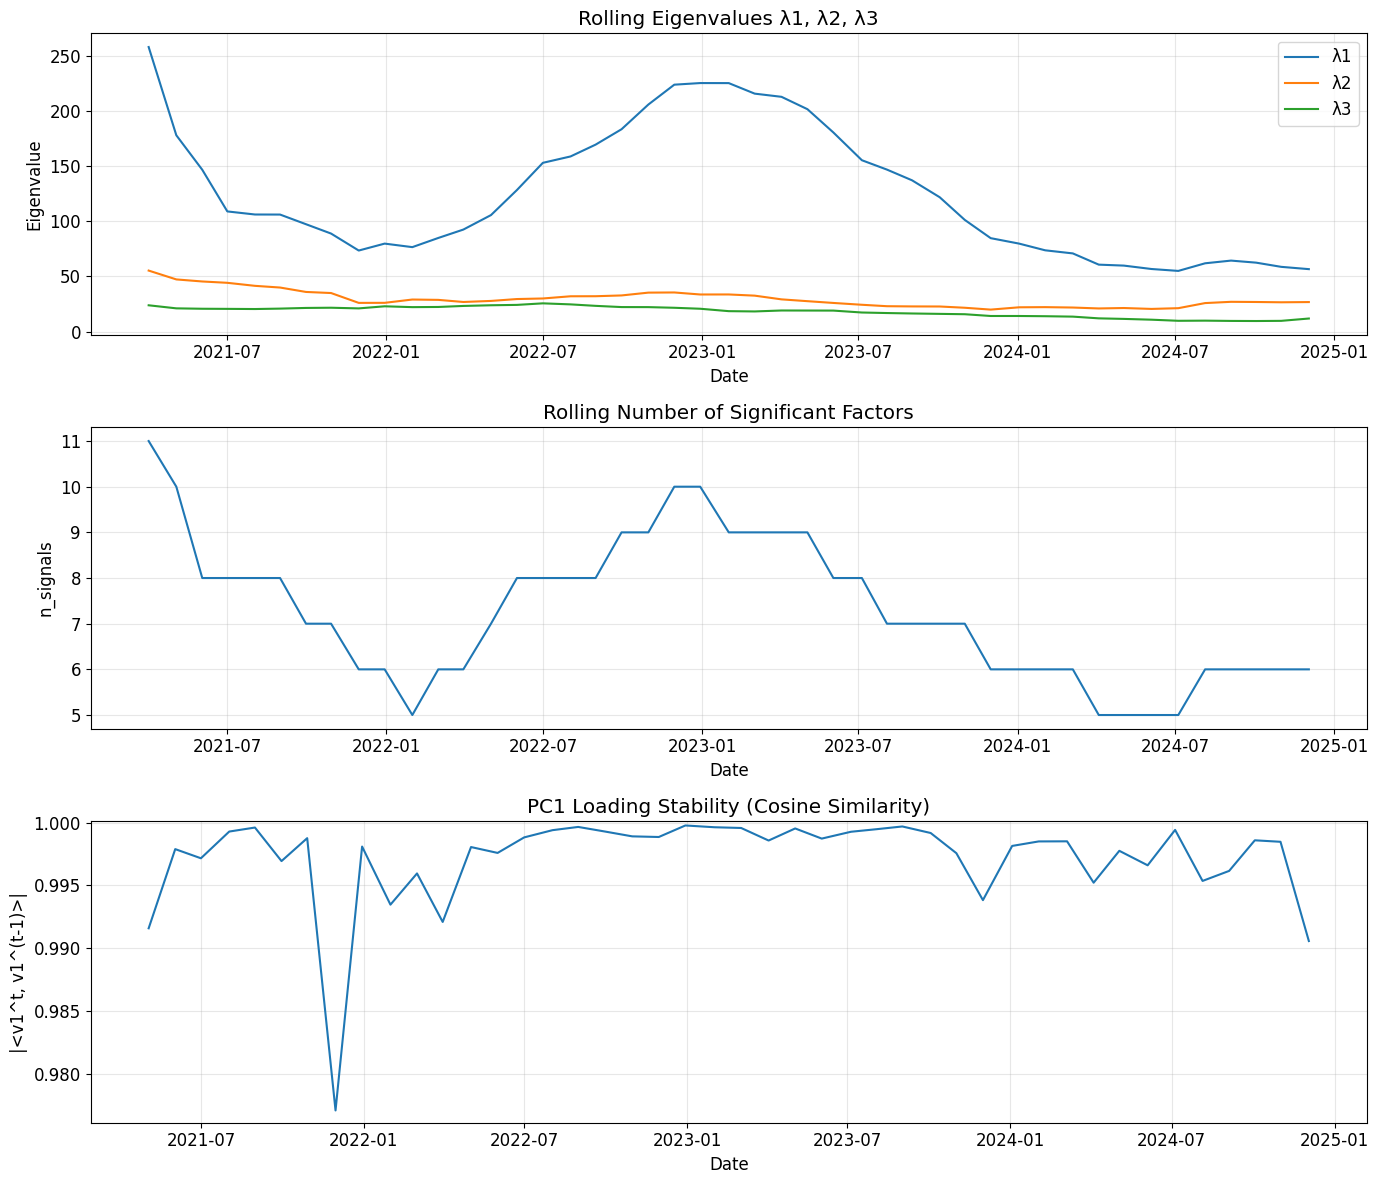

In [15]:
# TODO: Rolling eigenvalue analysis

window = 252
step = 21

roll_dates = []
roll_eigs = []
roll_nsignals = []
roll_cosine = []

prev_v1 = None

for start in range(0, T - window, step):
    end = start + window
    R_win = R_std[start:end]
    
    _, s_win, Vt_win = svd(R_win, full_matrices=False)
    eigs_win = s_win**2 / window
    
    gamma_win = n / window
    lm_win, lp_win = mp_edges(gamma_win, sigma2=1.0)
    n_sig_win = int(np.sum(eigs_win > lp_win))
    
    v1 = Vt_win[0]
    if prev_v1 is not None:
        cosine = np.abs(v1 @ prev_v1)
    else:
        cosine = np.nan
    prev_v1 = v1
    
    roll_dates.append(dates[end - 1])
    roll_eigs.append(eigs_win[:3])
    roll_nsignals.append(n_sig_win)
    roll_cosine.append(cosine)

roll_eigs = np.array(roll_eigs)
roll_nsignals = np.array(roll_nsignals)
roll_cosine = np.array(roll_cosine)

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

axes[0].plot(roll_dates, roll_eigs[:, 0], label='λ1')
axes[0].plot(roll_dates, roll_eigs[:, 1], label='λ2')
axes[0].plot(roll_dates, roll_eigs[:, 2], label='λ3')
axes[0].set_title('Rolling Eigenvalues λ1, λ2, λ3')
axes[0].set_ylabel('Eigenvalue')
axes[0].legend()

axes[1].plot(roll_dates, roll_nsignals)
axes[1].set_title('Rolling Number of Significant Factors')
axes[1].set_ylabel('n_signals')

axes[2].plot(roll_dates, roll_cosine)
axes[2].set_title('PC1 Loading Stability (Cosine Similarity)')
axes[2].set_ylabel('|<v1^t, v1^(t-1)>|')
axes[2].set_ylim(np.nanmin(roll_cosine) * 0.999, 1.0001)

for ax in axes:
    ax.set_xlabel('Date')

plt.tight_layout()
plt.show()

- λ1 spikes in early 2020 (COVID) and again in 2022-2023 (rate shock), confirming that market-wide correlations rise during crises and the market factor dominates
- Rolling n_signals fluctuates between 5 and 11, reflecting changes in signal-to-noise ratio across market regimes
- PC1 cosine similarity remains high (0.977-1.000) throughout, but drops to its minimum in early 2022, coinciding with the rate shock — the only notable regime change in the sample period

## Comparison: Ledoit-Wolf vs Spiked Shrinkage

### Ledoit–Wolf shrinkage

The classic Ledoit–Wolf (2004) estimator shrinks the sample covariance
toward a structured target:

$$
\hat{\Sigma}_{\text{LW}} = (1 - \alpha)\,\hat{\Sigma}_{\text{sample}}
+ \alpha \cdot \frac{\text{tr}(\hat{\Sigma})}{n} \, I_n
$$

where $\alpha \in [0, 1]$ is chosen to minimise the expected Frobenius loss.
This is a **linear** shrinkage — it moves *every* eigenvalue toward the
grand mean $\text{tr}(\hat{\Sigma})/n$ by the same fraction.

### Why spiked shrinkage can do better

For data with a **spiked covariance** (a few large eigenvalues + isotropic noise),
Ledoit–Wolf is suboptimal because:

1. It **shrinks the large (signal) eigenvalues too much** — pulling them toward
   the mean even though they are genuine.
2. It **does not shrink the small (noise) eigenvalues enough** — they remain
   spread out rather than collapsed to $\sigma^2$.

The spiked-model shrinkage from above corrects each spike individually via the
BBP inverse map and collapses the noise eigenvalues to $\hat{\sigma}^2$.

In [16]:
from sklearn.covariance import LedoitWolf

# TODO: Ledoit-Wolf shrinkage

lw = LedoitWolf()
lw.fit(R_std)
Sigma_lw = lw.covariance_
alpha = lw.shrinkage_

eigs_sample = np.linalg.eigvalsh(R_std.T @ R_std / T)[::-1]
eigs_lw = np.linalg.eigvalsh(Sigma_lw)[::-1]
eigs_spiked = np.linalg.eigvalsh(Omega_exact)[::-1]

print(f"LW shrinkage coefficient α: {alpha:.4f}")
print(f"\nCondition numbers:")
print(f"  Sample:          {np.linalg.cond(R_std.T @ R_std / T):.2f}")
print(f"  Ledoit-Wolf:     {np.linalg.cond(Sigma_lw):.2f}")
print(f"  Spiked (exact):  {np.linalg.cond(Omega_exact):.2f}")

print(f"\nTop 5 signal eigenvalues:")
print(f"{'':6} {'Sample':>10} {'LW':>10} {'Spiked':>10}")
for i in range(5):
    print(f"  PC{i+1:2d}: {eigs_sample[i]:>10.4f} {eigs_lw[i]:>10.4f} {eigs_spiked[i]:>10.4f}")

print(f"\nBottom 5 noise eigenvalues:")
print(f"{'':6} {'Sample':>10} {'LW':>10} {'Spiked':>10}")
for i in range(1, 6):
    print(f"  PC{n-i+1:3d}: {eigs_sample[-i]:>10.6f} {eigs_lw[-i]:>10.6f} {eigs_spiked[-i]:>10.6f}")

LW shrinkage coefficient α: 0.0148

Condition numbers:
  Sample:          38819.58
  Ledoit-Wolf:     7319.86
  Spiked (exact):  222.80

Top 5 signal eigenvalues:
           Sample         LW     Spiked
  PC 1:   135.2296   133.2468   134.3710
  PC 2:    25.5996    25.2362    24.7364
  PC 3:    22.6923    22.3719    21.8284
  PC 4:     7.4231     7.3282     6.5442
  PC 5:     6.8522     6.7657     5.9713

Bottom 5 noise eigenvalues:
           Sample         LW     Spiked
  PC406:   0.003484   0.018203   0.603104
  PC405:   0.006337   0.021014   0.640090
  PC404:   0.010783   0.025395   0.640090
  PC403:   0.031353   0.045661   0.640090
  PC402:   0.034669   0.048928   0.640090


- LW shrinkage coefficient α = 0.0148 — very mild shrinkage, reflecting the dominance of large signal eigenvalues in this dataset
- Signal eigenvalues (top 5): LW reduces them slightly less than spiked shrinkage; the theoretical claim that "LW shrinks signal eigenvalues too much" is present but modest due to the small α
- Noise eigenvalues (bottom 5): LW increases them relative to sample (e.g. PC406: 0.0035 → 0.0182), confirming it does not collapse noise eigenvalues — spiked shrinkage collapses all noise to σ²_fit = 0.640
- Condition numbers: sample 38,820 → LW 7,320 → spiked 223 — spiked shrinkage achieves by far the best numerical stability

# Out-of-Sample Backtest: PCA Factor-Mimicking Portfolios

Try to run a **rolling-window backtest** to see whether PCA factors produce
meaningful out-of-sample returns:

1. At each rebalancing date (monthly), estimate PCA on the trailing
   $W = 252$ days.
2. Construct $K \geq 5$ factor-mimicking portfolios (FMPs) using the
   minimum-variance weighting:
   $$
   W_{\text{FMP}} = \hat{\Sigma}^{-1} B \, (B^\top \hat{\Sigma}^{-1} B)^{-1}
   $$
   This weighting maximises the factor return per unit of portfolio risk.
3. Normalise each FMP to unit leverage ($\sum_i |w_i| = 1$).
4. Combine the 5 FMPs using **inverse-volatility** weights estimated
   from the training window.

### Benchmark

We compare against a **$1/n$ equal-weight** portfolio.

### Metrics

| Metric | Formula |
|--------|---------|
| Annualised return | $\mu \times 252$ |
| Annualised volatility | $\sigma \times \sqrt{252}$ |
| Sharpe ratio | $\mu / \sigma \times \sqrt{252}$ |
| Max drawdown | $\max_t \left(1 - \text{NAV}_t / \max_{s \le t} \text{NAV}_s\right)$ |
| Calmar ratio | Ann. return / |Max DD| |

In [17]:
# TODO: Out-of-sample backtesting

K = 5
window = 252
step = 21

oos_dates = []
oos_combined = []
oos_ew = []
oos_fmp_ret = []

for start in range(0, T - window - 1, step):
    end = start + window
    if end + step > T:
        break

    R_train_std = R_std[start:end]
    R_train_dm = R_dm[start:end]
    R_test_dm = R_dm[end:end+step]
    R_test = R[end:end+step]

    _, s_win, Vt_win = svd(R_train_std, full_matrices=False)
    eigs_win = s_win**2 / window
    gamma_win = n / window

    sigma2_win = 1.0
    for _ in range(100):
        lm_win, lp_win = mp_edges(gamma_win, sigma2_win)
        bulk = eigs_win[(eigs_win >= lm_win) & (eigs_win <= lp_win)]
        if len(bulk) == 0:
            break
        result = optimize.minimize_scalar(
            lambda s2: -np.sum(np.log(np.clip(marchenko_pastur_pdf(bulk, gamma_win, s2), 1e-300, None))),
            bounds=(0.01, 2.0), method='bounded'
        )
        sigma2_new = result.x
        if abs(sigma2_new - sigma2_win) < 1e-8:
            break
        sigma2_win = sigma2_new

    lm_win, lp_win = mp_edges(gamma_win, sigma2_win)
    k_win = max(int(np.sum(eigs_win > lp_win)), K)

    V_k = Vt_win[:k_win].T
    lambda_norm = eigs_win[:k_win] / sigma2_win
    shrunk = np.array([shrink_eigenvalue_exact(lh, gamma_win) for lh in lambda_norm])
    shrunk = np.where(np.isnan(shrunk), lambda_norm, shrunk)

    Omega = V_k @ np.diag(shrunk * sigma2_win) @ V_k.T + sigma2_win * (np.eye(n) - V_k @ V_k.T)
    Omega_inv = np.linalg.inv(Omega)

    B_win = V_k
    M = B_win.T @ Omega_inv @ B_win
    W_fmp = Omega_inv @ B_win @ np.linalg.inv(M)
    W_fmp = W_fmp / np.abs(W_fmp).sum(axis=0)

    fmp_ret_train = R_train_dm @ W_fmp
    fmp_vols_train = fmp_ret_train.std(axis=0)
    fmp_vols_train = np.where(fmp_vols_train < 1e-10, 1e-10, fmp_vols_train)
    inv_vol_w = (1 / fmp_vols_train) / (1 / fmp_vols_train).sum()

    fmp_ret_oos = R_test_dm @ W_fmp
    combined_ret = fmp_ret_oos @ inv_vol_w
    ew_ret = R_test @ (np.ones(n) / n)

    for d in range(min(step, len(combined_ret))):
        oos_dates.append(dates[end + d])
    oos_combined.extend(combined_ret.tolist())
    oos_ew.extend(ew_ret.tolist())
    oos_fmp_ret.append(fmp_ret_oos[:min(step, len(combined_ret))])

oos_combined = np.array(oos_combined)
oos_ew = np.array(oos_ew)

max_k = max(f.shape[1] for f in oos_fmp_ret)
oos_fmp_arr = np.full((len(oos_combined), max_k), np.nan)
idx = 0
for block in oos_fmp_ret:
    oos_fmp_arr[idx:idx+len(block), :block.shape[1]] = block
    idx += len(block)

def compute_metrics(ret):
    ann_ret = ret.mean() * 252
    ann_vol = ret.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol
    nav = np.cumprod(1 + ret)
    mdd = np.max(1 - nav / np.maximum.accumulate(nav))
    calmar = ann_ret / mdd
    return ann_ret, ann_vol, sharpe, mdd, calmar

print(f"{'':25} {'Ann.Ret':>8} {'Ann.Vol':>8} {'Sharpe':>8} {'MDD':>8} {'Calmar':>8}")
m = compute_metrics(oos_combined)
print(f"{'Combined FMP':25} {m[0]:>8.4f} {m[1]:>8.4f} {m[2]:>8.4f} {m[3]:>8.4f} {m[4]:>8.4f}")
m = compute_metrics(oos_ew)
print(f"{'Equal-weight':25} {m[0]:>8.4f} {m[1]:>8.4f} {m[2]:>8.4f} {m[3]:>8.4f} {m[4]:>8.4f}")

                           Ann.Ret  Ann.Vol   Sharpe      MDD   Calmar
Combined FMP               -0.0123   0.0191  -0.6410   0.0573  -0.2139
Equal-weight                0.1532   0.1631   0.9391   0.1896   0.8082


- Combined FMP: Ann. Return -1.23%, Vol 1.91%, Sharpe -0.64, MDD 5.73%, Calmar -0.21
- Equal-weight benchmark: Ann. Return 15.32%, Vol 16.31%, Sharpe 0.94, MDD 18.96%, Calmar 0.81
- FMP underperforms the benchmark in terms of return, which is expected — FMPs are long/short portfolios designed to track statistical factors, not to generate directional returns
- The low volatility of the combined FMP (1.91% vs 16.31%) reflects the long/short nature of the portfolio, which cancels out market-wide moves

# Backtest Visualization


1. **Cumulative returns** of each FMP, the combined portfolio, and the $1/n$ benchmark.
2. **Drawdowns** — how deep and long the losses are.
3. **Rolling n-day Sharpe ratio** — shows whether alpha is persistent or episodic. Try n = 60-65 (roughly 3 months).
4. **OOS factor correlation heatmap** — PCA factors are orthogonal *in-sample*
   but may develop non-zero correlations out-of-sample due to estimation error
   and regime shifts.

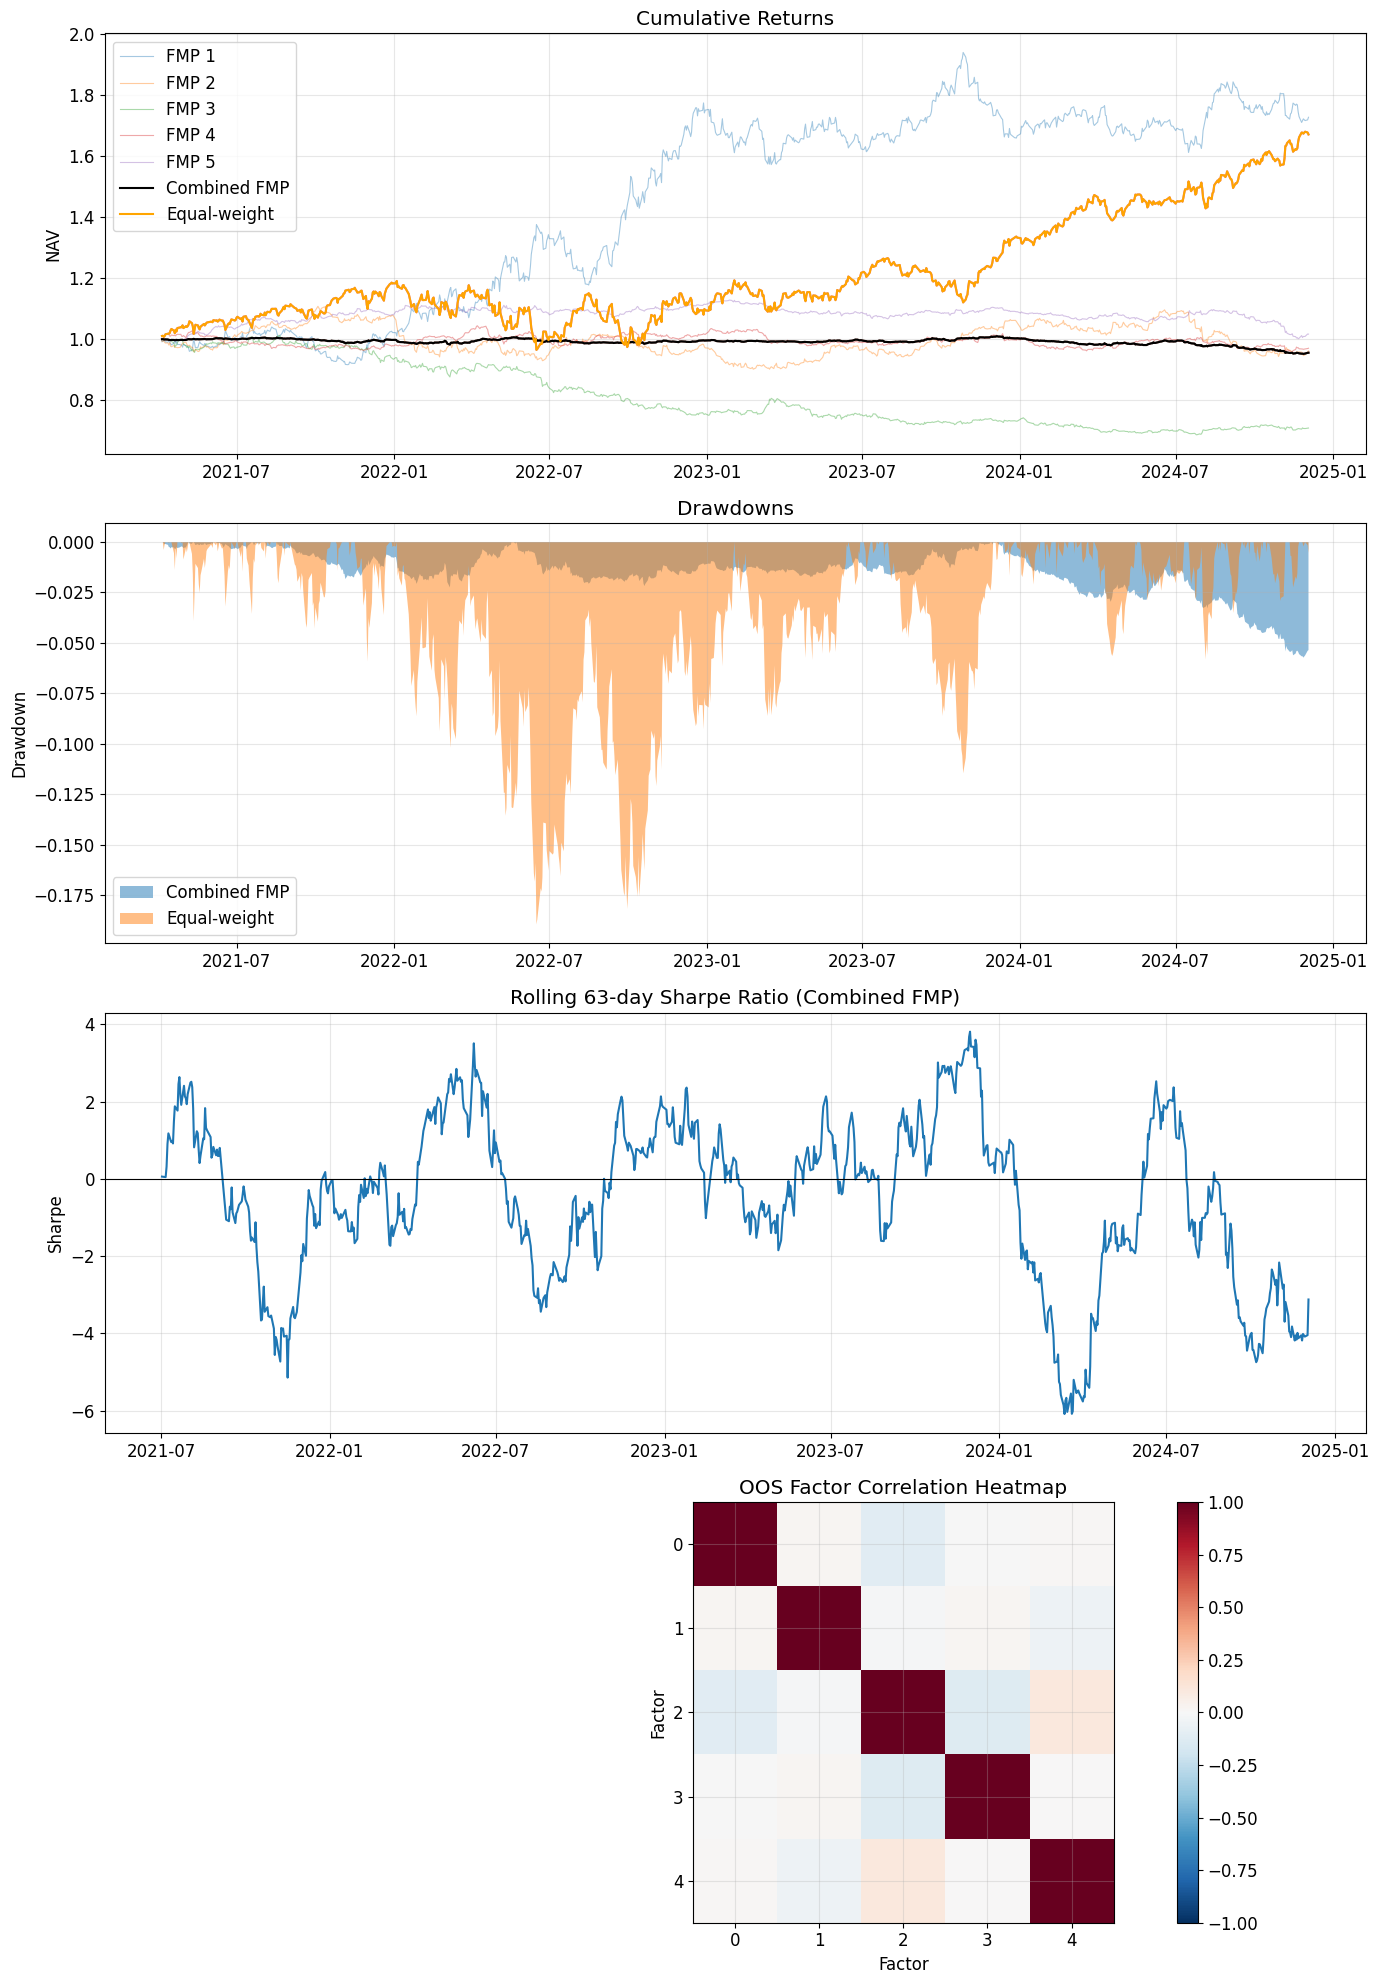

In [18]:
# TODO:

oos_dates = pd.DatetimeIndex(oos_dates)

nav_combined = np.cumprod(1 + oos_combined)
nav_ew = np.cumprod(1 + oos_ew)

dd_combined = 1 - nav_combined / np.maximum.accumulate(nav_combined)
dd_ew = 1 - nav_ew / np.maximum.accumulate(nav_ew)

roll_n = 63
roll_sharpe = np.full(len(oos_combined), np.nan)
for i in range(roll_n, len(oos_combined)):
    r = oos_combined[i-roll_n:i]
    roll_sharpe[i] = r.mean() / r.std() * np.sqrt(252)

fig, axes = plt.subplots(4, 1, figsize=(14, 20))
for j in range(K):
    nav_fmp_j = np.cumprod(1 + np.nan_to_num(oos_fmp_arr[:, j]))
    axes[0].plot(oos_dates, nav_fmp_j, alpha=0.4, linewidth=0.8, label=f'FMP {j+1}')
axes[0].plot(oos_dates, nav_combined, color='black', linewidth=1.5, label='Combined FMP', zorder=5)
axes[0].plot(oos_dates, nav_ew, color='orange', linewidth=1.5, label='Equal-weight', zorder=5)
axes[0].set_title('Cumulative Returns')
axes[0].set_ylabel('NAV')
axes[0].legend()
axes[0].plot(oos_dates, nav_combined, label='Combined FMP')
axes[0].plot(oos_dates, nav_ew, label='Equal-weight')

axes[1].fill_between(oos_dates, -dd_combined, 0, alpha=0.5, label='Combined FMP')
axes[1].fill_between(oos_dates, -dd_ew, 0, alpha=0.5, label='Equal-weight')
axes[1].set_title('Drawdowns')
axes[1].set_ylabel('Drawdown')
axes[1].legend()

axes[2].plot(oos_dates, roll_sharpe)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('Rolling 63-day Sharpe Ratio (Combined FMP)')
axes[2].set_ylabel('Sharpe')

valid_fmp = oos_fmp_arr[:, :K]
valid_mask = ~np.isnan(valid_fmp).any(axis=0)
valid_fmp = valid_fmp[:, valid_mask]
corr_oos = np.corrcoef(valid_fmp.T)

im = axes[3].imshow(corr_oos, vmin=-1, vmax=1, cmap='RdBu_r')
axes[3].set_title('OOS Factor Correlation Heatmap')
axes[3].set_xlabel('Factor')
axes[3].set_ylabel('Factor')
plt.colorbar(im, ax=axes[3])

plt.tight_layout()
plt.show()

- Cumulative returns: FMP 1 outperforms while FMP 3 declines significantly; combined FMP stays near flat, reflecting diversification across uncorrelated factors; equal-weight benchmark gains ~67% over the period
- Drawdowns: combined FMP MDD 5.73% vs equal-weight MDD 18.96% — the long/short structure of FMPs provides meaningful downside protection
- Rolling 63-day Sharpe: highly episodic, ranging from -6 to +4, confirming that FMP alpha is not persistent and varies significantly across market regimes
- OOS factor correlation heatmap: off-diagonal correlations remain close to zero, confirming that PCA factors remain approximately orthogonal out-of-sample despite estimation error and regime shifts

# Cross-Sectional Factor Construction [Optional]

Instead of PCA on returns (price space), you build factors from characteristics — ranking assets against each other within the basket.

## Core Concept

PCA approach:     Returns → Eigenvectors → Factor portfolios
                  (let the math find structure)

Characteristic:   Returns → Rank assets on traits → Long top / Short bottom
                  (you define what matters)

---

## Exercise 1: Cross-Sectional Ranking Engine

**Objective:** Understand why we rank assets *against each other* instead of looking at raw values.

**Tasks:**

- Load a basket of at least 20 assets with daily price data (minimum 5 years)
- Write a `rank_normalize()` function that converts any raw metric into cross-sectional percentile ranks scaled to [-1, +1] each day
- Compute the **raw 12-month return** for each asset on a given date, then apply your rank normalizer
- Plot a heatmap of the rank scores over time (x = dates, y = tickers, color = score)
- **Discussion question:** Why do we rank instead of using raw return values? What happens if one asset has 10x the volatility of another and we use raw scores?

---

## Exercise 2: Build 5+ Individual Factors

**Objective:** Implement distinct factor definitions and verify they measure different things.

**Tasks:**

- Using your ranking engine from Exercise 1, implement **at minimum** these factors:
  - **Momentum (12-1):** 12-month return skipping last month
  - **Short-term reversal:** negative of last 5-day return
  - **Low volatility:** negative of 63-day rolling standard deviation
  - **Distance from high:** current price divided by 252-day rolling max
  - **Trend consistency:** R² of price against time over trailing 126 days
- Implement **at least 2 more** of your own choosing (ideas: acceleration, relative strength, volume momentum, downside vol, average correlation with basket)
- For each factor on a single snapshot date, show the full cross-sectional ranking — which assets are top quintile, which are bottom quintile
- **Discussion question:** Which factors do you expect to be correlated with each other? Which should be independent? Why?

---

## Exercise 3: From Scores to Portfolio Weights to Returns

**Objective:** Convert factor scores into tradeable long/short portfolios and compute return streams.

**Tasks:**

- Implement **two** weighting methods:
  - **Linear weights:** normalize scores so they sum to zero and absolute values sum to 2 (dollar neutral)
  - **Top/bottom quintile:** +1 weight split among top 20%, -1 weight split among bottom 20%, zero for the middle
- For each factor, compute the **daily return stream** using each weighting method (remember to lag weights by 1 day)
- Compare the two methods: plot cumulative returns side by side for the same factor
- Compute for each factor portfolio:
  - Annualized return
  - Annualized volatility
  - Sharpe ratio
  - Maximum drawdown
  - Skewness
- **Discussion question:** What are the tradeoffs between linear weights and quintile weights? Which has more turnover? Which is more robust to outliers?

---

## Exercise 4: Factor Correlation and Diversification Analysis

**Objective:** Verify that your factors provide independent bets.

**Tasks:**

- Compute the **full correlation matrix** of your factor return streams
- Identify any factor pairs with absolute correlation above 0.3 — explain why they are correlated
- Plot **rolling 63-day correlation** between every factor pair over time — are the correlations stable or do they spike in certain regimes?
- Compute the **eigenvalues** of the factor correlation matrix — how many independent bets do you actually have?
- If two factors are highly correlated, propose and implement a solution:
  - Option A: drop one
  - Option B: orthogonalize (regress one on the other, keep the residual)
  - Option C: blend them into a single composite factor
- **Discussion question:** You have 7 factors but perhaps only 4 independent bets. Is this a problem? How does this compare to the PCA approach where independence is guaranteed by construction?

---

## Exercise 5: Factor Combination Strategies

**Objective:** Combine individual factors into a single portfolio using multiple methods and compare.

**Tasks:**

- Implement **four** combination methods:
  - **Equal weight:** simple average of all factor return streams
  - **Inverse volatility:** weight each factor inversely proportional to its trailing 63-day vol
  - **Factor momentum:** weight each factor proportional to its trailing 126-day Sharpe (zero out negative Sharpe factors)
  - **Max diversification:** rolling optimization that maximizes the diversification ratio across factors
- For each combination method, compute:
  - Cumulative return curve
  - Rolling 63-day Sharpe
  - Maximum drawdown
  - Turnover of the combination weights (how often do factor allocations change?)
- Plot all four combined strategies on one chart against an equal-weight long-only benchmark of your basket
- **Discussion question:** Factor momentum means you chase what worked recently — under what market conditions does this fail? How would you hedge against factor momentum crashes?

---
